# CTR Prediction Benchmark: Standard vs ZeroFLOPS

- Standard: FeatureHashing → Embedding → MLP
- ZeroFLOPS: Head/Mid/Tail splitting → Embedding riêng → Concat → MLP

## 0. Cài đặt thư viện

In [1]:
!pip install datasets -q

## 1. Import & Config

In [2]:
import os
import math
import time
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import roc_auc_score, log_loss
from datasets import load_dataset

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Hyperparameters ─────────────────────────────────────────────────────────
SAMPLE_FRAC   = 0.1        
BATCH_SIZE    = 4096
EPOCHS        = 15
LR            = 1e-3
EMBED_DIM     = 16          
MLP_DIMS      = [512, 256, 128] 
DROPOUT       = 0.2

# ── Feature columns ─────────────────────────────────────────────────────────
INT_COLS  = [f'I{i}' for i in range(1, 14)]   
CAT_COLS  = [f'C{i}' for i in range(1, 27)]  
LABEL_COL = 'label'

# ── ZeroFLOPS thresholds ─────────────────────────────────────────────────────
HEAD_THRESHOLD = 100   
MID_THRESHOLD  = 10    
HASH_BUCKETS   = 1000  

print('Config loaded ✓')

Using device: cuda
GPU: Tesla T4
Config loaded ✓


## 2. Load Data từ HuggingFace

In [3]:
print('Loading dataset từ HuggingFace...')
ds = load_dataset('nmpogg/criteo-cleaned', split='train')

# Lấy 5%
n_total  = len(ds)
n_sample = int(n_total * SAMPLE_FRAC)
print(f'Total: {n_total:,} rows  →  Sample 5%: {n_sample:,} rows')

ds_sample = ds.select(range(n_sample))
df = ds_sample.to_pandas()

# Train / Val split: 90/10
split_idx = int(len(df) * 0.9)
df_train  = df.iloc[:split_idx].reset_index(drop=True)
df_val    = df.iloc[split_idx:].reset_index(drop=True)
print(f'Train: {len(df_train):,}  |  Val: {len(df_val):,}')
df.head(3)

Loading dataset từ HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

data/train-00000-of-00050.parquet:   0%|          | 0.00/67.7M [00:00<?, ?B/s]

...

data/train-00049-of-00050.parquet:   0%|          | 0.00/73.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45840617 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Total: 45,840,617 rows  →  Sample 5%: 4,584,061 rows
Train: 4,125,654  |  Val: 458,407


,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,...,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,1,1,5,0,1382,4,15,2,181,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,unknown,3a171ecb,c5c50484,e8b83407,9727dd16
1,0,2,0,44,1,102,8,2,2,4,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,unknown,3a171ecb,43f13e8b,e8b83407,731c3655
2,0,2,0,1,14,767,89,4,2,245,...,8efede7f,3412118d,unknown,unknown,e587c466,ad3062eb,3a171ecb,3b183c5c,unknown,unknown


## 3. Preprocessing

In [4]:
# ── 3.1 Integer features: điền median, clip outliers, normalize ─────────────
int_medians = df_train[INT_COLS].median()

def preprocess_int(df_in, medians):
    df_out = df_in[INT_COLS].copy()
    df_out = df_out.fillna(medians)
    df_out = df_out.clip(lower=0)                         # loại âm
    df_out = df_out.apply(lambda x: np.log1p(x))         # log transform
    df_out = (df_out - df_out.mean()) / (df_out.std() + 1e-8)  # normalize
    return df_out.values.astype(np.float32)

int_train = preprocess_int(df_train, int_medians)
int_val   = preprocess_int(df_val,   int_medians)
print(f'Integer features shape: {int_train.shape}')

# ── 3.2 Labels ───────────────────────────────────────────────────────────────
y_train = df_train[LABEL_COL].values.astype(np.float32)
y_val   = df_val[LABEL_COL].values.astype(np.float32)
print(f'Label distribution (train): {y_train.mean():.4f} positive rate')

Integer features shape: (4125654, 13)
Label distribution (train): 0.2512 positive rate


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# STANDARD: FeatureHashing cho tất cả 26 cột categorical
# ════════════════════════════════════════════════════════════════════════════
def feature_hashing(series, n_buckets=HASH_BUCKETS):
    """Hash string values về [0, n_buckets)"""
    return series.apply(
        lambda x: int(hash(str(x)) % n_buckets) if pd.notna(x) else 0
    ).values.astype(np.int64)

print('Building Standard (FeatureHashing) features...')
cat_standard_train = np.stack(
    [feature_hashing(df_train[c]) for c in CAT_COLS], axis=1
)  # shape: (N, 26)
cat_standard_val = np.stack(
    [feature_hashing(df_val[c]) for c in CAT_COLS], axis=1
)
print(f'Standard cat features shape: {cat_standard_train.shape}')

Building Standard (FeatureHashing) features...
Standard cat features shape: (4125654, 26)


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# ZEROFLOPS: Phân nhóm Head / Mid / Tail theo tần suất
# ════════════════════════════════════════════════════════════════════════════

# Bước 1: Đếm tần suất trên tập train
freq_maps = {}   # freq_maps[col][value] = count
for col in CAT_COLS:
    freq_maps[col] = df_train[col].value_counts().to_dict()

# Bước 2: Tạo StringIndex cho HEAD và MID
# Với mỗi cột: value → index (riêng biệt cho head và mid)
head_vocab = {}  # head_vocab[col] = {value: idx}
mid_vocab  = {}  # mid_vocab[col]  = {value: idx}

for col in CAT_COLS:
    freq = freq_maps[col]
    head_vals = [v for v, c in freq.items() if c >= HEAD_THRESHOLD]
    mid_vals  = [v for v, c in freq.items() if MID_THRESHOLD <= c < HEAD_THRESHOLD]
    # idx bắt đầu từ 1 (0 dành cho unknown/OOV)
    head_vocab[col] = {v: i+1 for i, v in enumerate(head_vals)}
    mid_vocab[col]  = {v: i+1 for i, v in enumerate(mid_vals)}

head_vocab_sizes = {col: len(head_vocab[col]) + 1 for col in CAT_COLS}
mid_vocab_sizes  = {col: len(mid_vocab[col])  + 1 for col in CAT_COLS}

print('Vocab sizes (sample 5 cols):')
for col in CAT_COLS[:5]:
    print(f'  {col}: HEAD={head_vocab_sizes[col]}, MID={mid_vocab_sizes[col]}')

# Bước 3: Chuyển data sang index
def encode_zeroflops(df_in):
    head_idx = np.zeros((len(df_in), len(CAT_COLS)), dtype=np.int64)
    mid_idx  = np.zeros((len(df_in), len(CAT_COLS)), dtype=np.int64)
    tail_idx = np.zeros((len(df_in), len(CAT_COLS)), dtype=np.int64)

    for i, col in enumerate(CAT_COLS):
        freq = freq_maps[col]
        hv   = head_vocab[col]
        mv   = mid_vocab[col]

        for row_idx, val in enumerate(df_in[col]):
            cnt = freq.get(str(val), 0)
            if cnt >= HEAD_THRESHOLD:
                head_idx[row_idx, i] = hv.get(str(val), 0)
            elif cnt >= MID_THRESHOLD:
                mid_idx[row_idx, i]  = mv.get(str(val), 0)
            else:  # TAIL
                tail_idx[row_idx, i] = int(hash(str(val)) % HASH_BUCKETS)
    return head_idx, mid_idx, tail_idx

print('Encoding ZeroFLOPS train...')
t0 = time.time()
head_train, mid_train, tail_train = encode_zeroflops(df_train)
print(f'  Done in {time.time()-t0:.1f}s')

print('Encoding ZeroFLOPS val...')
t0 = time.time()
head_val, mid_val, tail_val = encode_zeroflops(df_val)
print(f'  Done in {time.time()-t0:.1f}s')
print(f'Head shape: {head_train.shape}  Mid: {mid_train.shape}  Tail: {tail_train.shape}')

Vocab sizes (sample 5 cols):
  C1: HEAD=201, MID=477
  C2: HEAD=469, MID=61
  C3: HEAD=2553, MID=19314
  C4: HEAD=3304, MID=19694
  C5: HEAD=70, MID=115
Encoding ZeroFLOPS train...
  Done in 49.2s
Encoding ZeroFLOPS val...
  Done in 5.6s
Head shape: (4125654, 26)  Mid: (4125654, 26)  Tail: (4125654, 26)


## 4. PyTorch Dataset

In [7]:
class StandardDataset(Dataset):
    def __init__(self, int_feats, cat_feats, labels):
        self.int_feats = torch.tensor(int_feats, dtype=torch.float32)
        self.cat_feats = torch.tensor(cat_feats, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.int_feats[idx], self.cat_feats[idx], self.labels[idx]


class ZeroFLOPSDataset(Dataset):
    def __init__(self, int_feats, head_idx, mid_idx, tail_idx, labels):
        self.int_feats = torch.tensor(int_feats, dtype=torch.float32)
        self.head_idx  = torch.tensor(head_idx,  dtype=torch.long)
        self.mid_idx   = torch.tensor(mid_idx,   dtype=torch.long)
        self.tail_idx  = torch.tensor(tail_idx,  dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.int_feats[idx], self.head_idx[idx],
                self.mid_idx[idx], self.tail_idx[idx], self.labels[idx])


# Tạo DataLoaders
train_standard_loader = DataLoader(
    StandardDataset(int_train, cat_standard_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_standard_loader = DataLoader(
    StandardDataset(int_val, cat_standard_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

train_zeroflops_loader = DataLoader(
    ZeroFLOPSDataset(int_train, head_train, mid_train, tail_train, y_train),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
val_zeroflops_loader = DataLoader(
    ZeroFLOPSDataset(int_val, head_val, mid_val, tail_val, y_val),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches: {len(train_standard_loader)}')
print(f'Val batches:   {len(val_standard_loader)}')

Train batches: 1008
Val batches:   112


## 5. Model Definitions

In [8]:
def build_mlp(input_dim, hidden_dims, dropout):
    """Xây MLP với BatchNorm + Dropout"""
    layers = []
    in_dim = input_dim
    for h in hidden_dims:
        layers += [
            nn.Linear(in_dim, h),
            nn.BatchNorm1d(h),
            nn.ReLU(),
            nn.Dropout(dropout)
        ]
        in_dim = h
    layers.append(nn.Linear(in_dim, 1))
    return nn.Sequential(*layers)

In [9]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 1: Standard
# Pipeline: cat_hash → Embedding → flatten → concat int → MLP
# ════════════════════════════════════════════════════════════════════════════
class StandardModel(nn.Module):
    def __init__(self, n_cat_cols, hash_buckets, embed_dim,
                 n_int_feats, mlp_dims, dropout):
        super().__init__()
        # 1 embedding table dùng chung cho tất cả cột (vì đều dùng same hash space)
        self.embedding  = nn.Embedding(hash_buckets, embed_dim, padding_idx=0)
        self.n_cat_cols = n_cat_cols

        # Input MLP = embed_dim * n_cat_cols + n_int_feats
        mlp_input_dim = embed_dim * n_cat_cols + n_int_feats
        self.mlp = build_mlp(mlp_input_dim, mlp_dims, dropout)

    def forward(self, int_x, cat_x):
        # cat_x: (B, 26) → embedding → (B, 26, embed_dim) → flatten (B, 26*embed_dim)
        emb = self.embedding(cat_x)           # (B, 26, embed_dim)
        emb = emb.view(emb.size(0), -1)       # (B, 26*embed_dim)

        x   = torch.cat([emb, int_x], dim=1) # (B, 26*embed_dim + 13)
        out = self.mlp(x).squeeze(-1)         # (B,)
        return out


standard_model = StandardModel(
    n_cat_cols  = len(CAT_COLS),
    hash_buckets= HASH_BUCKETS,
    embed_dim   = EMBED_DIM,
    n_int_feats = len(INT_COLS),
    mlp_dims    = MLP_DIMS,
    dropout     = DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in standard_model.parameters())
print(f'Standard Model parameters: {n_params:,}')
print(standard_model)

Standard Model parameters: 402,305
StandardModel(
  (embedding): Embedding(1000, 16, padding_idx=0)
  (mlp): Sequential(
    (0): Linear(in_features=429, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 2: ZeroFLOPS
# Pipeline:
#   HEAD → StringIndex → EmbHead → project → embed_dim
#   MID  → StringIndex → EmbMid  → project → embed_dim
#   TAIL → HashIndex   → EmbTail → project → embed_dim
#   3 phần concat với int → MLP
# ════════════════════════════════════════════════════════════════════════════
class ZeroFLOPSModel(nn.Module):
    def __init__(self, head_vocab_sizes, mid_vocab_sizes,
                 hash_buckets, embed_dim,
                 n_int_feats, mlp_dims, dropout):
        super().__init__()

        self.n_cols    = len(CAT_COLS)
        self.embed_dim = embed_dim

        # Embedding riêng cho từng cột, từng nhóm
        self.head_embs = nn.ModuleList([
            nn.Embedding(head_vocab_sizes[col], embed_dim, padding_idx=0)
            for col in CAT_COLS
        ])
        self.mid_embs  = nn.ModuleList([
            nn.Embedding(mid_vocab_sizes[col], embed_dim, padding_idx=0)
            for col in CAT_COLS
        ])
        # TAIL dùng chung 1 embedding table (giống Standard)
        self.tail_emb  = nn.Embedding(hash_buckets, embed_dim, padding_idx=0)

        # Input MLP = embed_dim * n_cols * 3 + n_int_feats
        # (mỗi cột có 3 vector: head, mid, tail → sau đó sum/mean để về embed_dim)
        mlp_input_dim = embed_dim * self.n_cols + n_int_feats
        self.mlp = build_mlp(mlp_input_dim, mlp_dims, dropout)

    def forward(self, int_x, head_x, mid_x, tail_x):
        # Với mỗi cột i, lấy embedding từ cả 3 nhóm rồi cộng lại
        # (chỉ 1 trong 3 nhóm có giá trị != 0 padding)
        col_embs = []
        for i in range(self.n_cols):
            e_head = self.head_embs[i](head_x[:, i])  # (B, embed_dim)
            e_mid  = self.mid_embs[i](mid_x[:, i])    # (B, embed_dim)
            e_tail = self.tail_emb(tail_x[:, i])       # (B, embed_dim)
            # Cộng: chỉ 1 trong 3 != 0 (vì các idx kia = 0 = padding)
            col_embs.append(e_head + e_mid + e_tail)   # (B, embed_dim)

        emb = torch.stack(col_embs, dim=1)  # (B, n_cols, embed_dim)
        emb = emb.view(emb.size(0), -1)     # (B, n_cols * embed_dim)

        x   = torch.cat([emb, int_x], dim=1)
        out = self.mlp(x).squeeze(-1)
        return out


zeroflops_model = ZeroFLOPSModel(
    head_vocab_sizes = head_vocab_sizes,
    mid_vocab_sizes  = mid_vocab_sizes,
    hash_buckets     = HASH_BUCKETS,
    embed_dim        = EMBED_DIM,
    n_int_feats      = len(INT_COLS),
    mlp_dims         = MLP_DIMS,
    dropout          = DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in zeroflops_model.parameters())
print(f'ZeroFLOPS Model parameters: {n_params:,}')
print(zeroflops_model)

ZeroFLOPS Model parameters: 3,349,169
ZeroFLOPSModel(
  (head_embs): ModuleList(
    (0): Embedding(201, 16, padding_idx=0)
    (1): Embedding(469, 16, padding_idx=0)
    (2): Embedding(2553, 16, padding_idx=0)
    (3): Embedding(3304, 16, padding_idx=0)
    (4): Embedding(70, 16, padding_idx=0)
    (5): Embedding(12, 16, padding_idx=0)
    (6): Embedding(5002, 16, padding_idx=0)
    (7): Embedding(116, 16, padding_idx=0)
    (8): Embedding(4, 16, padding_idx=0)
    (9): Embedding(4095, 16, padding_idx=0)
    (10): Embedding(2997, 16, padding_idx=0)
    (11): Embedding(2608, 16, padding_idx=0)
    (12): Embedding(2461, 16, padding_idx=0)
    (13): Embedding(26, 16, padding_idx=0)
    (14): Embedding(2802, 16, padding_idx=0)
    (15): Embedding(2833, 16, padding_idx=0)
    (16): Embedding(11, 16, padding_idx=0)
    (17): Embedding(1592, 16, padding_idx=0)
    (18): Embedding(764, 16, padding_idx=0)
    (19): Embedding(5, 16, padding_idx=0)
    (20): Embedding(2673, 16, padding_idx=0)
  

## 6. Training Loop

In [11]:
def train_standard_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for int_x, cat_x, y in loader:
        int_x, cat_x, y = int_x.to(DEVICE), cat_x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        preds = model(int_x, cat_x)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def train_zeroflops_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for int_x, head_x, mid_x, tail_x, y in loader:
        int_x  = int_x.to(DEVICE)
        head_x = head_x.to(DEVICE)
        mid_x  = mid_x.to(DEVICE)
        tail_x = tail_x.to(DEVICE)
        y      = y.to(DEVICE)
        optimizer.zero_grad()
        preds = model(int_x, head_x, mid_x, tail_x)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate_standard(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for int_x, cat_x, y in loader:
        int_x, cat_x = int_x.to(DEVICE), cat_x.to(DEVICE)
        preds = torch.sigmoid(model(int_x, cat_x)).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    return roc_auc_score(labels, preds), log_loss(labels, preds)


@torch.no_grad()
def evaluate_zeroflops(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for int_x, head_x, mid_x, tail_x, y in loader:
        int_x  = int_x.to(DEVICE)
        head_x = head_x.to(DEVICE)
        mid_x  = mid_x.to(DEVICE)
        tail_x = tail_x.to(DEVICE)
        preds  = torch.sigmoid(model(int_x, head_x, mid_x, tail_x)).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(y.numpy())
    preds  = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)
    return roc_auc_score(labels, preds), log_loss(labels, preds)


print('Training utilities ready ✓')

Training utilities ready ✓


In [12]:
# ════════════════════════════════════════════════════════════════════════════
# TRAIN Standard
# ════════════════════════════════════════════════════════════════════════════
print('=' * 60)
print('Training STANDARD model')
print('=' * 60)

criterion_std  = nn.BCEWithLogitsLoss()
optimizer_std  = torch.optim.Adam(standard_model.parameters(), lr=LR)
scheduler_std  = torch.optim.lr_scheduler.StepLR(optimizer_std, step_size=1, gamma=0.5)

std_history = []
for epoch in range(1, EPOCHS + 1):
    t0       = time.time()
    tr_loss  = train_standard_epoch(standard_model, train_standard_loader,
                                    optimizer_std, criterion_std)
    auc, ll  = evaluate_standard(standard_model, val_standard_loader)
    elapsed  = time.time() - t0
    scheduler_std.step()
    std_history.append({'epoch': epoch, 'loss': tr_loss, 'auc': auc, 'logloss': ll})
    print(f'[Epoch {epoch}/{EPOCHS}]  Loss: {tr_loss:.4f}  '
          f'AUC: {auc:.4f}  LogLoss: {ll:.4f}  Time: {elapsed:.1f}s')

Training STANDARD model
[Epoch 1/15]  Loss: 0.4833  AUC: 0.7669  LogLoss: 0.4705  Time: 38.9s
[Epoch 2/15]  Loss: 0.4687  AUC: 0.7741  LogLoss: 0.4654  Time: 39.5s
[Epoch 3/15]  Loss: 0.4636  AUC: 0.7764  LogLoss: 0.4633  Time: 35.8s
[Epoch 4/15]  Loss: 0.4608  AUC: 0.7781  LogLoss: 0.4620  Time: 37.4s
[Epoch 5/15]  Loss: 0.4590  AUC: 0.7786  LogLoss: 0.4616  Time: 38.7s
[Epoch 6/15]  Loss: 0.4581  AUC: 0.7788  LogLoss: 0.4616  Time: 40.8s
[Epoch 7/15]  Loss: 0.4576  AUC: 0.7790  LogLoss: 0.4614  Time: 40.4s
[Epoch 8/15]  Loss: 0.4575  AUC: 0.7790  LogLoss: 0.4614  Time: 40.0s
[Epoch 9/15]  Loss: 0.4573  AUC: 0.7790  LogLoss: 0.4613  Time: 37.3s
[Epoch 10/15]  Loss: 0.4572  AUC: 0.7791  LogLoss: 0.4613  Time: 41.4s
[Epoch 11/15]  Loss: 0.4572  AUC: 0.7791  LogLoss: 0.4613  Time: 35.7s
[Epoch 12/15]  Loss: 0.4572  AUC: 0.7791  LogLoss: 0.4613  Time: 35.8s
[Epoch 13/15]  Loss: 0.4572  AUC: 0.7791  LogLoss: 0.4613  Time: 41.5s
[Epoch 14/15]  Loss: 0.4573  AUC: 0.7791  LogLoss: 0.4613  Tim

In [13]:
# ════════════════════════════════════════════════════════════════════════════
# TRAIN ZeroFLOPS
# ════════════════════════════════════════════════════════════════════════════
print('=' * 60)
print('Training ZEROFLOPS model')
print('=' * 60)

criterion_zf  = nn.BCEWithLogitsLoss()
optimizer_zf  = torch.optim.Adam(zeroflops_model.parameters(), lr=LR)
scheduler_zf  = torch.optim.lr_scheduler.StepLR(optimizer_zf, step_size=1, gamma=0.5)

zf_history = []
for epoch in range(1, EPOCHS + 1):
    t0      = time.time()
    tr_loss = train_zeroflops_epoch(zeroflops_model, train_zeroflops_loader,
                                    optimizer_zf, criterion_zf)
    auc, ll = evaluate_zeroflops(zeroflops_model, val_zeroflops_loader)
    elapsed = time.time() - t0
    scheduler_zf.step()
    zf_history.append({'epoch': epoch, 'loss': tr_loss, 'auc': auc, 'logloss': ll})
    print(f'[Epoch {epoch}/{EPOCHS}]  Loss: {tr_loss:.4f}  '
          f'AUC: {auc:.4f}  LogLoss: {ll:.4f}  Time: {elapsed:.1f}s')

Training ZEROFLOPS model
[Epoch 1/15]  Loss: 0.4801  AUC: 0.7743  LogLoss: 0.4652  Time: 65.8s
[Epoch 2/15]  Loss: 0.4621  AUC: 0.7804  LogLoss: 0.4607  Time: 64.3s
[Epoch 3/15]  Loss: 0.4561  AUC: 0.7833  LogLoss: 0.4584  Time: 65.6s
[Epoch 4/15]  Loss: 0.4528  AUC: 0.7847  LogLoss: 0.4572  Time: 69.7s
[Epoch 5/15]  Loss: 0.4509  AUC: 0.7852  LogLoss: 0.4569  Time: 71.9s
[Epoch 6/15]  Loss: 0.4500  AUC: 0.7854  LogLoss: 0.4567  Time: 68.3s
[Epoch 7/15]  Loss: 0.4496  AUC: 0.7855  LogLoss: 0.4567  Time: 69.7s
[Epoch 8/15]  Loss: 0.4493  AUC: 0.7855  LogLoss: 0.4566  Time: 68.5s
[Epoch 9/15]  Loss: 0.4492  AUC: 0.7855  LogLoss: 0.4567  Time: 65.2s
[Epoch 10/15]  Loss: 0.4492  AUC: 0.7855  LogLoss: 0.4566  Time: 67.8s
[Epoch 11/15]  Loss: 0.4490  AUC: 0.7855  LogLoss: 0.4567  Time: 69.6s
[Epoch 12/15]  Loss: 0.4491  AUC: 0.7855  LogLoss: 0.4567  Time: 67.3s
[Epoch 13/15]  Loss: 0.4491  AUC: 0.7855  LogLoss: 0.4567  Time: 66.7s
[Epoch 14/15]  Loss: 0.4490  AUC: 0.7855  LogLoss: 0.4566  Ti

## 7. Kết quả So sánh


FINAL RESULTS (last epoch)
Method               AUC    LogLoss
-----------------------------------
Standard          0.7791     0.4614
ZeroFLOPS         0.7855     0.4566


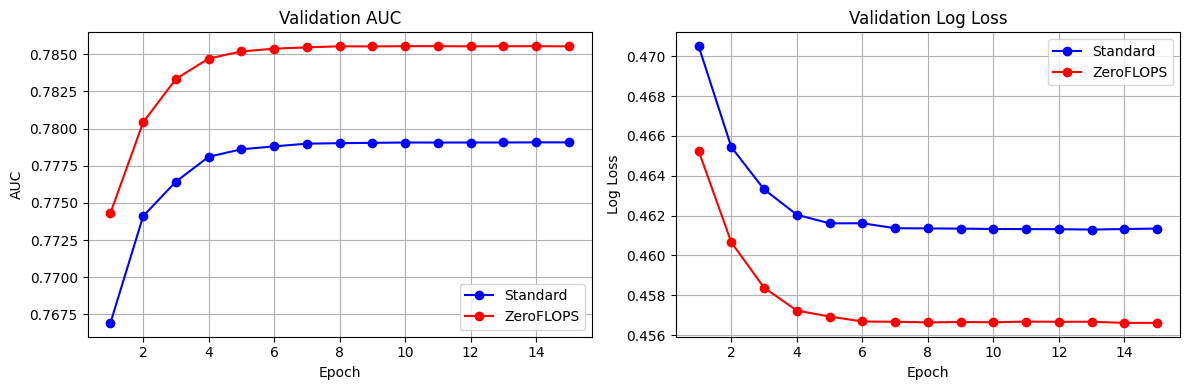


Plot saved to benchmark_results.png


In [14]:
import matplotlib.pyplot as plt

std_df = pd.DataFrame(std_history)
zf_df  = pd.DataFrame(zf_history)

print('\n' + '=' * 50)
print('FINAL RESULTS (last epoch)')
print('=' * 50)
print(f"{'Method':<15} {'AUC':>8} {'LogLoss':>10}")
print('-' * 35)
print(f"{'Standard':<15} {std_df['auc'].iloc[-1]:>8.4f} {std_df['logloss'].iloc[-1]:>10.4f}")
print(f"{'ZeroFLOPS':<15} {zf_df['auc'].iloc[-1]:>8.4f} {zf_df['logloss'].iloc[-1]:>10.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(std_df['epoch'], std_df['auc'], 'b-o', label='Standard')
axes[0].plot(zf_df['epoch'],  zf_df['auc'],  'r-o', label='ZeroFLOPS')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
axes[0].set_title('Validation AUC'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(std_df['epoch'], std_df['logloss'], 'b-o', label='Standard')
axes[1].plot(zf_df['epoch'],  zf_df['logloss'],  'r-o', label='ZeroFLOPS')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Log Loss')
axes[1].set_title('Validation Log Loss'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150)
plt.show()
print('\nPlot saved to benchmark_results.png')

In [15]:
# Lưu model weights
torch.save(standard_model.state_dict(),  'standard_model.pt')
torch.save(zeroflops_model.state_dict(), 'zeroflops_model.pt')
print('Models saved ✓')

Models saved ✓
